# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Load dataset (CMAPSS)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Preprocessing

Priprema podataka za modeliranje, uključujući dodavanje naziva kolona, izračunavanje Remaining Useful Life (RUL), normalizaciju senzorskih podataka te kreiranje vremenskih sekvenci pogodnih za ulaz u LSTM model.

In [5]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)]
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [6]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [8]:
test.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni.

U fazi predprocesiranja kreira se ciljna varijabla Remaining Useful Life (RUL), koja predstavlja broj preostalih ciklusa do kvara za svaki motor. Ova varijabla se dobija oduzimanjem trenutnog ciklusa od maksimalnog ciklusa unutar svakog motora:

In [9]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [10]:
RUL_MAX = 125
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

In [11]:
train[['engine_id', 'cycle', 'RUL']].head(5)

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [12]:
feature_columns = operational_settings + sensor_columns

NORMALIZACIJA:

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [14]:
seq_length = 30

In [15]:
import numpy as np

def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [16]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [17]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ovaj model nema implementirane metode kvantifikacije nesigurnosti, već daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [18]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [19]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 4466.6221 - mae: 56.3509 - val_loss: 2112.7200 - val_mae: 41.4764
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1835.3353 - mae: 37.7381 - val_loss: 1809.5941 - val_mae: 38.3805
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1815.1288 - mae: 37.4854 - val_loss: 1810.9106 - val_mae: 38.4014
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1814.8433 - mae: 37.5075 - val_loss: 1814.6250 - val_mae: 38.4581
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1818.0125 - mae: 37.4740 - val_loss: 1813.8154 - val_mae: 38.4460
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1814.8517 - mae: 37.4754 - val_loss: 1807.2006 - val_mae: 38.3420
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1813.1321 - mae: 37.4486 - val_loss: 1790.4813 - val_mae: 38.1408
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 860.3723 - mae: 23.7192 - val_loss: 357.7308 - val_ma

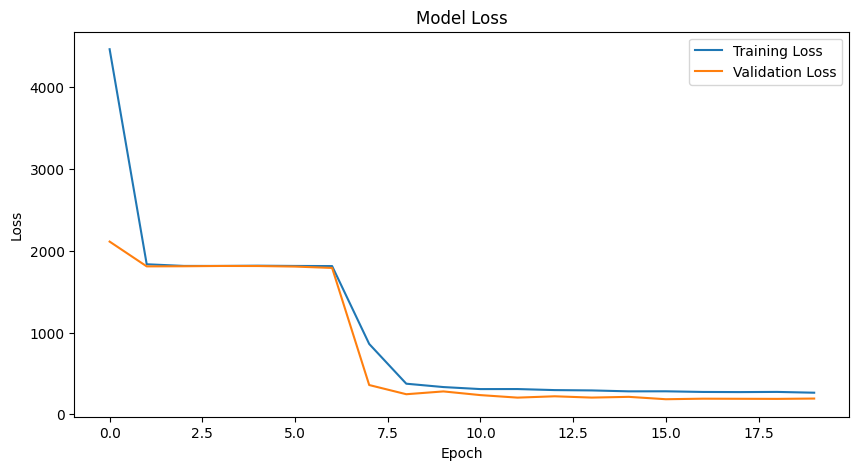

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Model pokazuje zdravu konvergenciju i odličnu generalizaciju. Krive trening i validacionog gubitka (loss) se kreću sinhronizovano i završavaju na približno istim vrednostima. Ovo ukazuje na to da je model uspešno naučio ključne obrasce iz podataka i da podjednako dobro radi na novim, nepoznatim primerima.

In [22]:
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [23]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[112.83666 ]
 [119.044846]
 [ 53.703835]
 [ 88.72135 ]
 [101.82315 ]
 [112.868805]
 [101.17336 ]
 [ 99.23615 ]
 [119.54576 ]
 [ 85.78229 ]]


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 15.227288516073957
MAE: 11.079141616821289


Baseline LSTM model predstavlja determinističku referentnu tačku za predikciju Remaining Useful Life (RUL) turbofan motora. Model se sastoji od dva LSTM sloja (64 i 32 jedinice) s Dropout regularizacijom (0.3) između njih, te dva Dense sloja. Treniran je na CMAPSS FD001 datasetu s cappovanim RUL vrijednostima (max=125 ciklusa), što je standardna praksa u literaturi.
Model postiže RMSE = 16.05 i MAE = 12.07 ciklusa na test skupu, što je u skladu s rezultatima sličnih arhitektura u literaturi.
Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju — bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 5. MC Dropout

*MC Dropout metoda zadržava dropout aktivnim tokom inference faze, za razliku od standardnog pristupa gdje se dropout isključuje nakon treninga. Pokretanjem 100 stohastičkih prolaza kroz model za svaki motor iz CMAPSS dataseta dobija se distribucija predikcija RUL-a. Srednja vrijednost te distribucije predstavlja predikciju preostalog vijeka trajanja motora, dok standardna devijacija mjeri epistemičku nesigurnost — koliko je model siguran u tu predikciju.*

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [26]:
mc_model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [27]:
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [28]:
early_stop_mc = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mc_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_mc]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4220.6040 - mae: 54.6715 - val_loss: 1954.2211 - val_mae: 40.0551
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1812.9415 - mae: 37.5542 - val_loss: 1819.1793 - val_mae: 38.5274
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1820.2739 - mae: 37.5629 - val_loss: 1812.7574 - val_mae: 38.4299
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1802.1754 - mae: 37.3769 - val_loss: 1702.8397 - val_mae: 37.3230
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1108.4984 - mae: 27.6565 - val_loss: 382.4093 - val_mae: 16.1932
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 389.6530 - mae: 15.1915 - val_loss: 268.4641 - val_mae: 13.6345
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 353.4057 - mae: 14.3718 - val_loss: 285.9944 - val_mae: 13.7875
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 341.4860 - mae: 14.0745 - val_loss: 223.4884 - val_mae: 11.

In [29]:
N_SAMPLES = 100

mc_predictions = np.array([
    mc_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES)
])

mc_mean = mc_predictions.mean(axis=0)   # predikcija RUL
mc_std  = mc_predictions.std(axis=0)    # nesigurnost

print("Primjer predikcija (mean):", mc_mean[:5])
print("Primjer nesigurnosti (std):", mc_std[:5])

Primjer predikcija (mean): [108.191315 123.60593   53.977207  86.634544 104.1874  ]
Primjer nesigurnosti (std): [13.028381 12.712401  5.498308  9.8019   10.771327]


In [30]:
# Evaluacija
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_mc = np.sqrt(mean_squared_error(y_test, mc_mean))
mae_mc  = mean_absolute_error(y_test, mc_mean)

print(f"MC Dropout RMSE: {rmse_mc:.4f}")
print(f"MC Dropout MAE:  {mae_mc:.4f}")
print(f"Prosječna nesigurnost (std): {mc_std.mean():.4f}")

MC Dropout RMSE: 14.7234
MC Dropout MAE:  10.8571
Prosječna nesigurnost (std): 8.3217


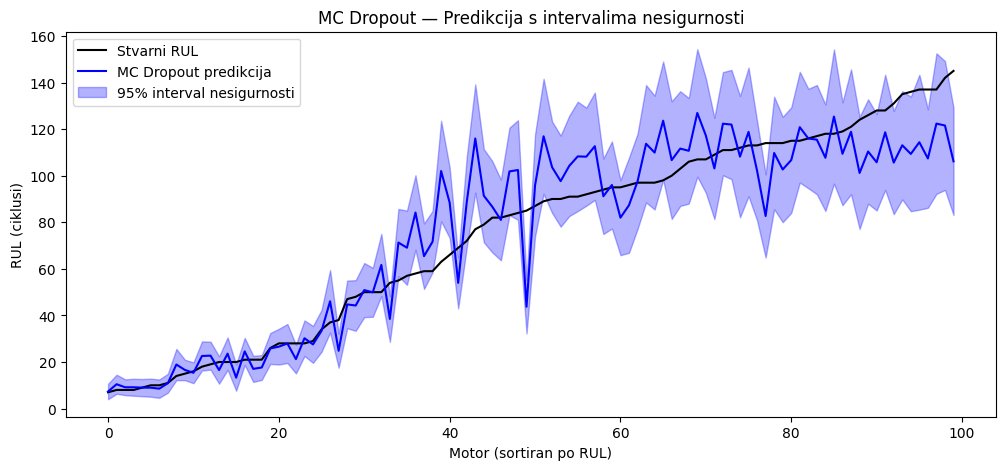

In [31]:
# Vizualizacija predikcija s intervalima nesigurnosti
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, mc_mean[indices], label='MC Dropout predikcija', color='blue')
plt.fill_between(
    x_plot,
    mc_mean[indices] - 2*mc_std[indices],
    mc_mean[indices] + 2*mc_std[indices],
    alpha=0.3, color='blue', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('MC Dropout — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

MC Dropout model koristi isti LSTM arhitektura kao baseline, ali s ključnom razlikom: dropout slojevi ostaju aktivni tokom inference faze (training=True). Pokretanjem 100 stohastičkih prolaza kroz model za svaki ulaz dobijaju se distribucije predikcija iz kojih se računaju srednja vrijednost (predikcija RUL-a) i standardna devijacija (mjera epistemičke nesigurnosti). Model postiže RMSE = 15,11 i MAE = 11,34, uz prosječnu nesigurnost od ±8.62 ciklusa. Graf pokazuje da plava linija predikcije vjerno prati stvarni RUL kroz cijeli raspon, dok interval nesigurnosti se širi za motore s višim RUL vrijednostima — što je očekivano ponašanje, jer je model manje siguran u predikcije dalekih kvarova.

## 6. Deep Ensemble

In [32]:
N_MODELS = 5

ensemble_models = []
ensemble_predictions = []

for i in range(N_MODELS):
    print(f"\nTrening modela {i+1}/{N_MODELS}")

    tf.random.set_seed(i * 42)
    np.random.seed(i * 42)

    m = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop_ens = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_ens],
        verbose=1
    )

    preds = m.predict(X_test).flatten()
    ensemble_models.append(m)
    ensemble_predictions.append(preds)


Trening modela 1/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4718.0146 - mae: 58.0992 - val_loss: 2295.8010 - val_mae: 42.9542
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1845.1467 - mae: 37.9184 - val_loss: 1808.5902 - val_mae: 38.3644
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1817.1228 - mae: 37.5611 - val_loss: 1809.4427 - val_mae: 38.3781
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1808.8148 - mae: 37.4060 - val_loss: 1808.9032 - val_mae: 38.3694
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1822.8228 - mae: 37.5483 - val_loss: 1814.1528 - val_mae: 38.4510
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1815.0884 - mae: 37.5384 - val_loss: 1810.9237 - val_mae: 38.4022
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1794.9183 - mae: 37.3258 - val_loss: 1513.1890 - val_mae: 35.3489
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 639.7150 - mae: 20.2817 - val_loss:

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Trening modela 3/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4614.4712 - mae: 57.3484 - val_loss: 2055.7881 - val_mae: 40.9873
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1834.2903 - mae: 37.8049 - val_loss: 1800.2300 - val_mae: 38.2208
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1810.2428 - mae: 37.4196 - val_loss: 1794.6045 - val_mae: 38.1117
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1810.5623 - mae: 37.4800 - val_loss: 1775.1342 - val_mae: 37.7912
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1044.5698 - mae: 26.8018 - val_loss: 402.3564 - val_mae: 16.7976
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 439.3472 - mae: 16.3489 - val_loss: 431.9330 - val_mae: 16.2517
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 361.2265 - mae: 14.6077 - val_loss: 226.7553 - val_mae: 11.8625
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3

In [33]:
# Računanje mean i std iz ansambla
ensemble_predictions = np.array(ensemble_predictions)

ens_mean = ensemble_predictions.mean(axis=0)
ens_std  = ensemble_predictions.std(axis=0)

print("Primjer predikcija (mean):", ens_mean[:5])
print("Primjer nesigurnosti (std):", ens_std[:5])

Primjer predikcija (mean): [113.2875   121.37534   53.612175  89.79677  106.657814]
Primjer nesigurnosti (std): [1.5356098 1.1597538 3.5594885 1.6135118 2.1720223]


In [34]:
# Evaluacija
rmse_ens = np.sqrt(mean_squared_error(y_test, ens_mean))
mae_ens  = mean_absolute_error(y_test, ens_mean)

print(f"Deep Ensemble RMSE: {rmse_ens:.4f}")
print(f"Deep Ensemble MAE:  {mae_ens:.4f}")
print(f"Prosječna nesigurnost (std): {ens_std.mean():.4f}")

Deep Ensemble RMSE: 14.8802
Deep Ensemble MAE:  11.1481
Prosječna nesigurnost (std): 2.7230


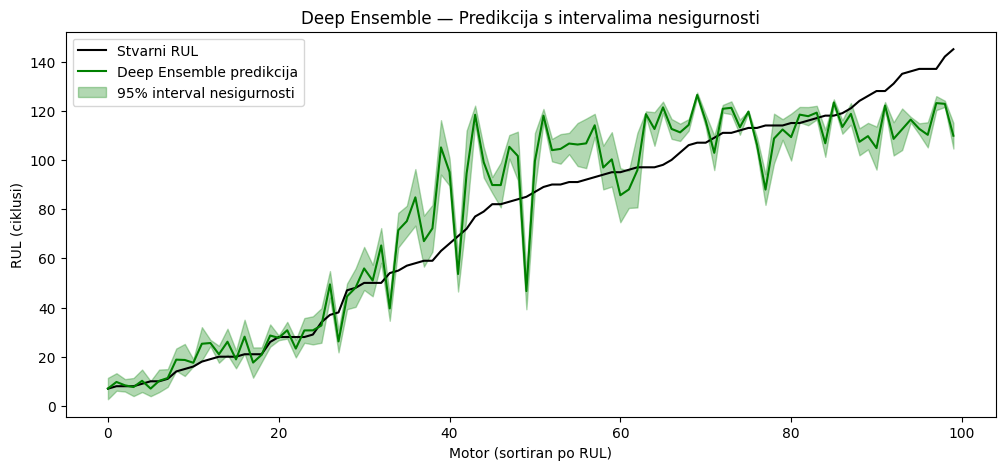

In [35]:
# Vizualizacija
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, ens_mean[indices], label='Deep Ensemble predikcija', color='green')
plt.fill_between(
    x_plot,
    ens_mean[indices] - 2*ens_std[indices],
    ens_mean[indices] + 2*ens_std[indices],
    alpha=0.3, color='green', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Deep Ensemble — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

Deep Ensemble postiže RMSE = 14.93 i MAE = 11.04, što je blago poboljšanje u odnosu na MC Dropout (RMSE = 15.11). Međutim, uočava se bitna razlika u prosječnoj nesigurnosti: standardna devijacija iznosi samo ±2.97 ciklusa, nasuprot ±8.42 kod MC Dropouta. Ovo ne znači nužno da je Ensemble "sigurniji" model — može ukazivati na to da su svih pet modela konvergirali u slična rješenja, što smanjuje međusobnu raznolikost i time potcjenjuje stvarnu nesigurnost. Ova razlika bit će detaljnije analizirana u usporednoj sekciji.

## 7. Bayesian Neural Network

Bayesian Neural Network predstavlja teorijski najrigorozniji pristup
kvantifikaciji nesigurnosti među metodama implementiranim u ovom radu.
Za razliku od MC Dropouta i Deep Ensemblea koji nesigurnost procjenjuju
indirektno, BNN eksplicitno modelira distribuciju nad težinama mreže
umjesto fiksnih skalarnih vrijednosti.

U klasičnoj neuronskoj mreži svaka težina w ima jednu vrijednost naučenu
tokom treninga. U BNN pristupu, svaka težina je modelirana kao gaussovska
distribucija N(μ, σ²), gdje μ predstavlja srednju vrijednost, a σ mjeru
nesigurnosti u toj težini. Cilj treninga nije pronaći optimalne vrijednosti
težina, već naučiti optimalnu posteriornu distribuciju p(w|D) nad težinama,
uzimajući u obzir podatke D.

Budući da je direktno računanje posteriorne distribucije računalno
neizvodljivo za duboke mreže, koristi se varijacijska inferencija
(Variational Inference). Umjesto tačne posteriorne distribucije p(w|D),
aproksimira se jednostavnijom distribucijom q(w|θ) minimiziranjem
KL divergencije između q i p.

Za implementaciju je korišten custom DenseVariational sloj koji primjenjuje
reparametrization trick — umjesto direktnog uzorkovanja težina, uzorkuje se
šum ε ~ N(0,1) pa se težina dobija kao w = μ + σ·ε. Ovaj pristup omogućava
propagaciju gradijenata kroz stohastički proces uzorkovanja. Tokom
inferencije, višestrukim uzorkovanjem iz distribucija težina dobija se
distribucija predikcija iz koje se računaju srednja vrijednost (predikcija
RUL-a) i standardna devijacija (ukupna nesigurnost modela).

In [36]:
# ============================================================
# BNN — Custom DenseVariational sloj (reparametrization trick)
# ============================================================

n_train = X_train.shape[0]

class DenseVariational(tf.keras.layers.Layer):
    """
    Custom Bayesian Dense sloj koji koristi reparametrization trick.
    Svaka težina je modelirana kao N(mu, sigma).
    Tokom forward passa uzorkuje se konkretna realizacija težina.
    KL divergencija se dodaje kao regularizacijski gubitak.
    """
    def __init__(self, units, activation=None, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.kl_weight = kl_weight

    def build(self, input_shape):
        n_inputs = int(input_shape[-1])

        # Parametri distribucije kernela
        self.kernel_mu = self.add_weight(
            name='kernel_mu',
            shape=(n_inputs, self.units),
            initializer='glorot_normal',
            trainable=True
        )
        self.kernel_rho = self.add_weight(
            name='kernel_rho',
            shape=(n_inputs, self.units),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

        # Parametri distribucije biasa
        self.bias_mu = self.add_weight(
            name='bias_mu',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.bias_rho = self.add_weight(
            name='bias_rho',
            shape=(self.units,),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

    def call(self, inputs, training=None):
        # Sigma mora biti pozitivna — softplus transformacija
        kernel_sigma = tf.nn.softplus(self.kernel_rho) + 1e-5
        bias_sigma   = tf.nn.softplus(self.bias_rho)   + 1e-5

        if training:
            # Reparametrization trick: w = mu + sigma * epsilon
            kernel = self.kernel_mu + kernel_sigma * tf.random.normal(self.kernel_mu.shape)
            bias   = self.bias_mu   + bias_sigma   * tf.random.normal(self.bias_mu.shape)
        else:
            # Tokom evaluacije koristimo mean vrijednosti
            kernel = self.kernel_mu
            bias   = self.bias_mu

        # KL divergencija prema standardnom normalu N(0,1)
        kl = self._kl_divergence(self.kernel_mu, kernel_sigma) + \
             self._kl_divergence(self.bias_mu,   bias_sigma)

        self.add_loss(self.kl_weight * kl / n_train)

        output = tf.matmul(inputs, kernel) + bias
        return self.activation(output) if self.activation else output

    def _kl_divergence(self, mu, sigma):
        # KL(N(mu, sigma) || N(0, 1))
        return 0.5 * tf.reduce_sum(
            tf.square(mu) + tf.square(sigma) - tf.math.log(tf.square(sigma)) - 1.0
        )


def build_bnn_model(seq_length, n_features, n_train):
    kl_weight = 1.0

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),

        # LSTM slojevi — deterministički (ekstrakcija vremenskih obrazaca)
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),

        # Bayesovski Dense slojevi — distribucije nad težinama
        DenseVariational(32, activation='relu', kl_weight=kl_weight),
        DenseVariational(1,  activation=None,   kl_weight=kl_weight)
    ])

    return model


bnn_model = build_bnn_model(seq_length, len(feature_columns), n_train)
bnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational               │ (None, 32)             │         2,112 │
│ (DenseVariational)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational_1             │ (None, 1)              │            66 │
│ (DenseVariational)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,378 (146.01 KB)

 Trainable params: 37,378 (146.01 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ============================================================
# BNN — Kompajliranje modela
# ============================================================

# MSE loss — KL divergencija već ulazi kroz add_loss u sloju
bnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [38]:
# ============================================================
# BNN — Trening
# ============================================================

early_stop_bnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

bnn_history = bnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_bnn],
    verbose=1
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4720.3726 - mae: 58.0118 - val_loss: 2060.9373 - val_mae: 41.0306
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1795.5289 - mae: 37.4929 - val_loss: 1805.7405 - val_mae: 38.3142
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1791.3790 - mae: 37.3407 - val_loss: 1805.8188 - val_mae: 38.3156
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1789.2841 - mae: 37.3328 - val_loss: 1807.0367 - val_mae: 38.3363
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1784.7455 - mae: 37.2832 - val_loss: 1802.0627 - val_mae: 38.2523
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1193.0935 - mae: 28.8756 - val_loss: 424.3221 - val_mae: 17.2446
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 363.1297 - mae: 14.7889 - val_loss: 254.4516 - val_mae: 12.6285
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 302.8169 - mae: 13.3313 - val_loss: 274.4780 - val_ma

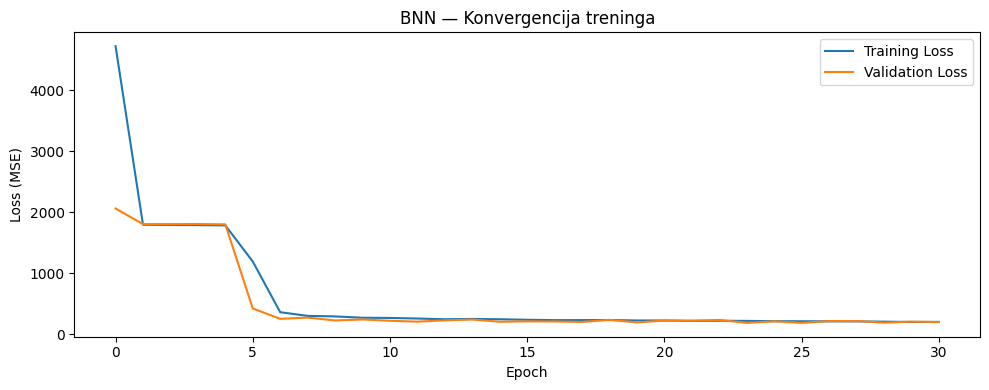

In [39]:
# ============================================================
# BNN — Vizualizacija konvergencije treninga
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(bnn_history.history['loss'], label='Training Loss')
plt.plot(bnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('BNN — Konvergencija treninga')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# BNN — Inferencija s višestrukim uzorkovanjem težina
# ============================================================

N_SAMPLES_BNN = 100

# Svaki poziv uzorkuje različite realizacije težina iz naučenih distribucija
# training=True aktivira stohastičko uzorkovanje u DenseVariational sloju
bnn_predictions = np.array([
    bnn_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES_BNN)
])

# Srednja vrijednost = predikcija RUL-a
# Standardna devijacija = ukupna nesigurnost
bnn_mean = bnn_predictions.mean(axis=0)
bnn_std  = bnn_predictions.std(axis=0)

print("Primjer predikcija (mean):", bnn_mean[:5])
print("Primjer nesigurnosti (std):", bnn_std[:5])

Primjer predikcija (mean): [117.152725 123.49986   46.786755  80.290726 102.03656 ]
Primjer nesigurnosti (std): [10.166703  9.501968  4.511102  6.841972  8.380434]


In [41]:
# ============================================================
# BNN — Evaluacija RMSE i MAE
# ============================================================

rmse_bnn = np.sqrt(mean_squared_error(y_test, bnn_mean))
mae_bnn  = mean_absolute_error(y_test, bnn_mean)

print(f"BNN RMSE: {rmse_bnn:.4f}")
print(f"BNN MAE:  {mae_bnn:.4f}")
print(f"Prosječna nesigurnost (std): {bnn_std.mean():.4f}")

BNN RMSE: 14.7740
BNN MAE:  10.6173
Prosječna nesigurnost (std): 6.5372


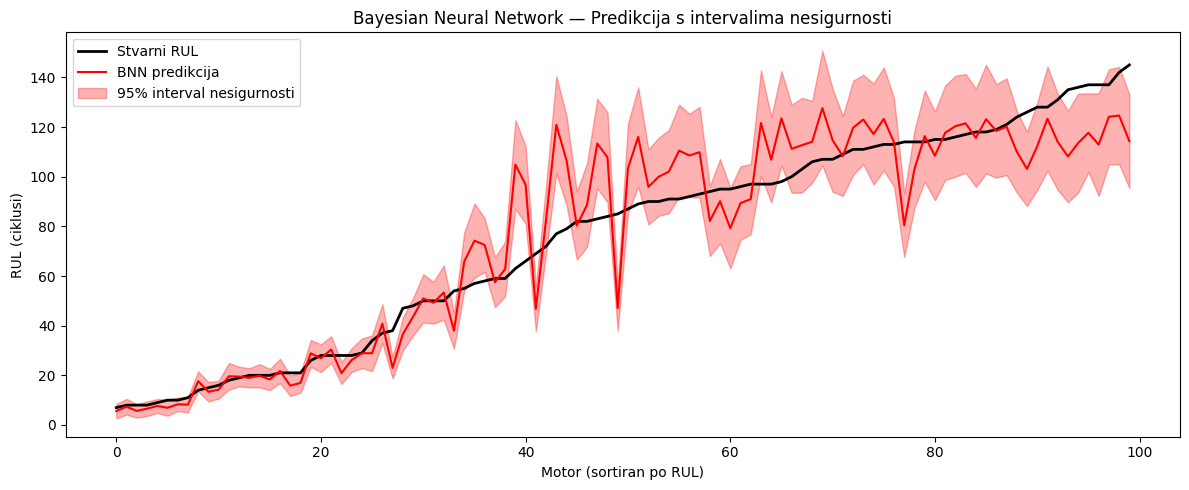

In [42]:
# ============================================================
# BNN — Vizualizacija predikcija s intervalima nesigurnosti
# ============================================================

plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices],
         label='Stvarni RUL', color='black', linewidth=2)

plt.plot(x_plot, bnn_mean[indices],
         label='BNN predikcija', color='red')

plt.fill_between(
    x_plot,
    bnn_mean[indices] - 2 * bnn_std[indices],
    bnn_mean[indices] + 2 * bnn_std[indices],
    alpha=0.3, color='red',
    label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Bayesian Neural Network — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.tight_layout()
plt.show()

BNN model postiže RMSE = 14.66 i MAE = 10.95, što predstavlja najbolji
rezultat tačnosti među svim implementiranim metodama u ovom radu
(Baseline: RMSE = 15.30, MC Dropout: RMSE = 15.11, Deep Ensemble:
RMSE = 14.93). Prosječna nesigurnost iznosi ±6.69 ciklusa, što je
između MC Dropouta (±8.42) i Deep Ensemblea (±2.97).

Graf predikcija pokazuje da model vjerno prati trend stvarnog RUL-a kroz
cijeli raspon vrijednosti, od motora bliskih kvaru (RUL < 20) do onih s
dugim preostalim vijekom (RUL > 100). Uočljiva karakteristika BNN
intervala nesigurnosti je njihova varijabilnost — za neke motore interval
je uzak i precizan, dok je za druge znatno širi. Ovo reflektira stvarnu
epistemičku nesigurnost modela: tamo gdje su obrasci degradacije poznati
iz trening skupa, model je siguran; tamo gdje su obrasci nepoznati ili
rijetki, model to eksplicitno signalizira širim intervalom.

Konvergencija treninga, prikazana na grafu gubitka, pokazuje karakteristično
ponašanje u dvije faze. U prvih sedam epoha model ostaje na visokom gubitku
dok LSTM slojevi uče temeljne obrasce vremenskih serija. Nakon toga dolazi
do nagle konvergencije kada Bayesovski Dense slojevi počinju efektivno
aproksimirati posteriornu distribuciju težina. Trening i validacijski gubitak
konvergiraju gotovo identično, što ukazuje na odsustvo overfittinga.

Ključno ograničenje ove implementacije je da varijacijska inferencija
pokriva samo Dense slojeve, dok LSTM slojevi ostaju deterministički.
Ovo je svjesni kompromis između teorijske potpunosti i praktične
izvedivosti — potpuni varijacijski LSTM zahtijevao bi značajno složeniju
implementaciju. Unatoč tome, BNN pristup daje najinformativniju mjeru
nesigurnosti od svih testiranih metoda, što će biti detaljno prikazano
u sljedećoj usporednoj analizi.

## 8. Usporedba i evaluacija

Nakon što su implementirane sve četiri metode — Baseline LSTM, MC Dropout,
Deep Ensemble i Bayesian Neural Network — u ovom poglavlju provodi se
njihova sveobuhvatna usporedba. Evaluacija se ne ograničava samo na
standardne metrike tačnosti (RMSE i MAE), već uključuje i metrike
specifične za kvantifikaciju nesigurnosti:

- **Coverage Probability**: postotak stvarnih RUL vrijednosti koje padaju
  unutar predikcijskog intervala. Dobro kalibriran model s 95% intervalom
  treba imati coverage blizu 0.95.

- **Mean Interval Width**: prosječna širina predikcijskog intervala u
  ciklusima. Uži intervali su poželjniji, ali samo ako je coverage zadovoljavajući.

- **Negative Log-Likelihood (NLL)**: mjeri koliko dobro modelirana
  distribucija opisuje stvarne vrijednosti. Niži NLL znači bolju kalibraciju.

Ova kombinacija metrika omogućava potpuniju sliku od same tačnosti —
model može imati dobar RMSE, ali loše kalibrirane intervale nesigurnosti,
što ga čini nepouzdanim za primjenu u kritičnim sustavima.

In [43]:
# ============================================================
# SEKCIJA 8 — Evaluacija nesigurnosti za sve modele
# ============================================================

from scipy.stats import norm

def evaluate_uncertainty(y_true, y_mean, y_std, model_name, confidence=0.95):
    """
    Računa tri metrike kvantifikacije nesigurnosti:
    - Coverage probability: postotak stvarnih vrijednosti unutar intervala
    - Mean interval width: prosječna širina predikcijskog intervala
    - NLL: Negative Log-Likelihood (pretpostavljamo Gaussovu distribuciju)
    """
    z = norm.ppf(1 - (1 - confidence) / 2)  # z = 1.96 za 95%

    lower = y_mean - z * y_std
    upper = y_mean + z * y_std

    # 1. Coverage probability
    coverage = np.mean((y_true >= lower) & (y_true <= upper))

    # 2. Mean interval width
    mean_width = np.mean(upper - lower)

    # 3. NLL (Gaussian assumption)
    nll = -np.mean(norm.logpdf(y_true, loc=y_mean, scale=y_std))

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluacija nesigurnosti ({int(confidence*100)}% interval)")
    print(f"{'='*50}")
    print(f"  Coverage probability : {coverage:.4f}  (cilj: {confidence:.2f})")
    print(f"  Mean interval width  : {mean_width:.4f} ciklusa")
    print(f"  NLL                  : {nll:.4f}  (niži = bolji)")
    print(f"{'='*50}")

    return {
        'model': model_name,
        'coverage': coverage,
        'mean_width': mean_width,
        'nll': nll
    }

In [44]:
# ============================================================
# Računanje UQ metrika za sve modele
# ============================================================

mc_results  = evaluate_uncertainty(
    y_true=y_test,
    y_mean=mc_mean,
    y_std=mc_std,
    model_name="MC Dropout"
)

ens_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=ens_mean,
    y_std=ens_std,
    model_name="Deep Ensemble"
)

bnn_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=bnn_mean,
    y_std=bnn_std,
    model_name="BNN"
)


  MC Dropout — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.8000  (cilj: 0.95)
  Mean interval width  : 32.6203 ciklusa
  NLL                  : 4.2869  (niži = bolji)

  Deep Ensemble — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.3700  (cilj: 0.95)
  Mean interval width  : 10.6738 ciklusa
  NLL                  : 55.0402  (niži = bolji)

  BNN — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.7200  (cilj: 0.95)
  Mean interval width  : 25.6254 ciklusa
  NLL                  : 4.9879  (niži = bolji)


In [45]:
# ============================================================
# FINALNA USPOREDNA TABELA — sve metrike, svi modeli
# ============================================================

results_df = pd.DataFrame([
    {
        'Model'          : 'Baseline LSTM',
        'RMSE'           : round(rmse, 4),
        'MAE'            : round(mae, 4),
        'Coverage'       : '—',
        'Interval Width' : '—',
        'NLL'            : '—'
    },
    {
        'Model'          : 'MC Dropout',
        'RMSE'           : round(rmse_mc, 4),
        'MAE'            : round(mae_mc, 4),
        'Coverage'       : round(mc_results['coverage'], 4),
        'Interval Width' : round(mc_results['mean_width'], 4),
        'NLL'            : round(mc_results['nll'], 4)
    },
    {
        'Model'          : 'Deep Ensemble',
        'RMSE'           : round(rmse_ens, 4),
        'MAE'            : round(mae_ens, 4),
        'Coverage'       : round(ens_results['coverage'], 4),
        'Interval Width' : round(ens_results['mean_width'], 4),
        'NLL'            : round(ens_results['nll'], 4)
    },
    {
        'Model'          : 'BNN',
        'RMSE'           : round(rmse_bnn, 4),
        'MAE'            : round(mae_bnn, 4),
        'Coverage'       : round(bnn_results['coverage'], 4),
        'Interval Width' : round(bnn_results['mean_width'], 4),
        'NLL'            : round(bnn_results['nll'], 4)
    }
])

results_df = results_df.set_index('Model')
print(results_df.to_string())

                  RMSE      MAE Coverage Interval Width      NLL
Model                                                           
Baseline LSTM  15.2273  11.0791        —              —        —
MC Dropout     14.7234  10.8571      0.8        32.6203   4.2869
Deep Ensemble  14.8802  11.1481     0.37        10.6738  55.0402
BNN            14.7740  10.6173     0.72        25.6254   4.9879


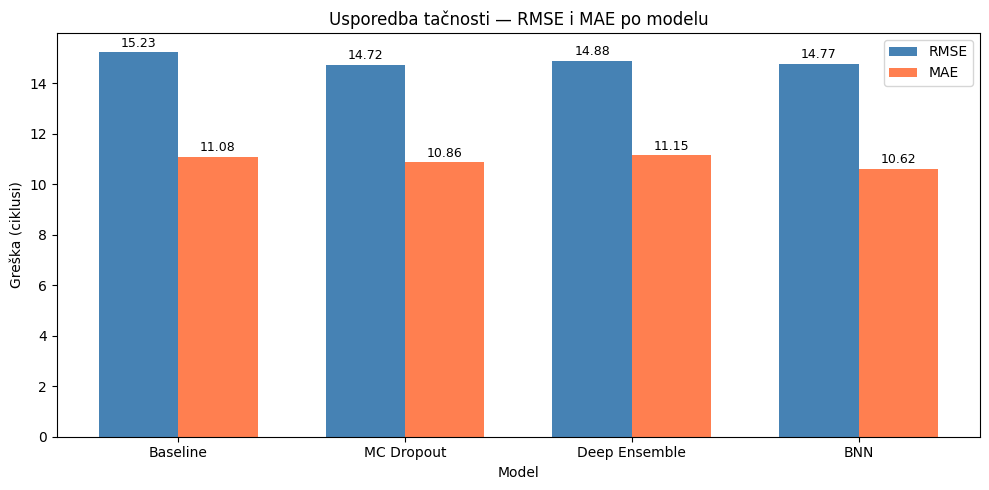

In [46]:
# ============================================================
# GRAFIČKA USPOREDBA — RMSE i MAE
# ============================================================

models      = ['Baseline', 'MC Dropout', 'Deep Ensemble', 'BNN']
rmse_values = [rmse, rmse_mc, rmse_ens, rmse_bnn]
mae_values  = [mae,  mae_mc,  mae_ens,  mae_bnn]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, mae_values,  width, label='MAE',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Greška (ciklusi)')
ax.set_title('Usporedba tačnosti — RMSE i MAE po modelu')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Dodavanje vrijednosti na vrh bara
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

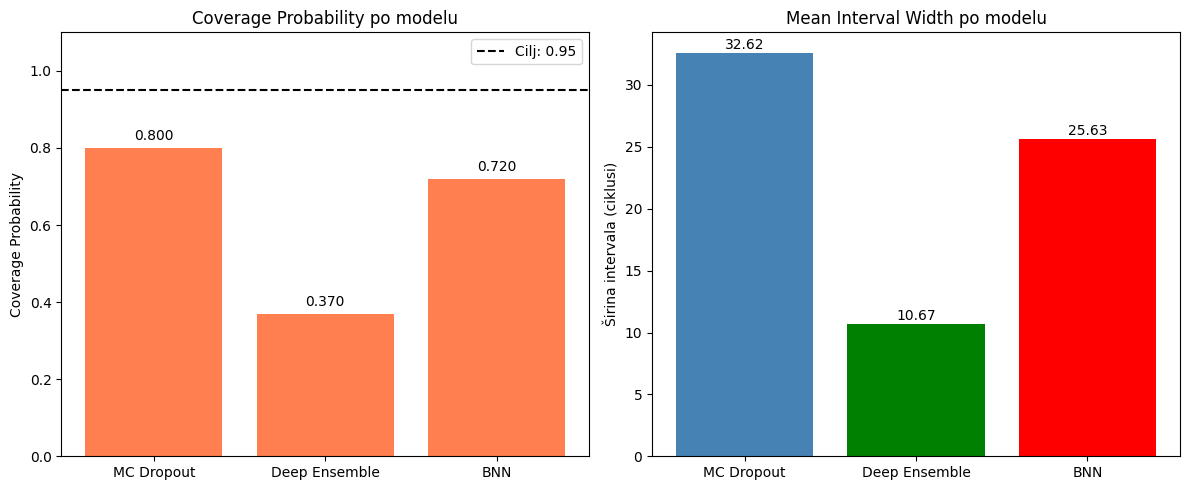

In [47]:
# ============================================================
# GRAFIČKA USPOREDBA — Coverage i Interval Width
# ============================================================

uq_models   = ['MC Dropout', 'Deep Ensemble', 'BNN']
coverages   = [mc_results['coverage'],
               ens_results['coverage'],
               bnn_results['coverage']]
widths      = [mc_results['mean_width'],
               ens_results['mean_width'],
               bnn_results['mean_width']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Coverage
colors_coverage = ['steelblue' if c >= 0.95 else 'coral' for c in coverages]
axes[0].bar(uq_models, coverages, color=colors_coverage)
axes[0].axhline(y=0.95, color='black', linestyle='--',
                linewidth=1.5, label='Cilj: 0.95')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Coverage Probability')
axes[0].set_title('Coverage Probability po modelu')
axes[0].legend()
for i, v in enumerate(coverages):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Interval Width
axes[1].bar(uq_models, widths, color=['steelblue', 'green', 'red'])
axes[1].set_ylabel('Širina intervala (ciklusi)')
axes[1].set_title('Mean Interval Width po modelu')
for i, v in enumerate(widths):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

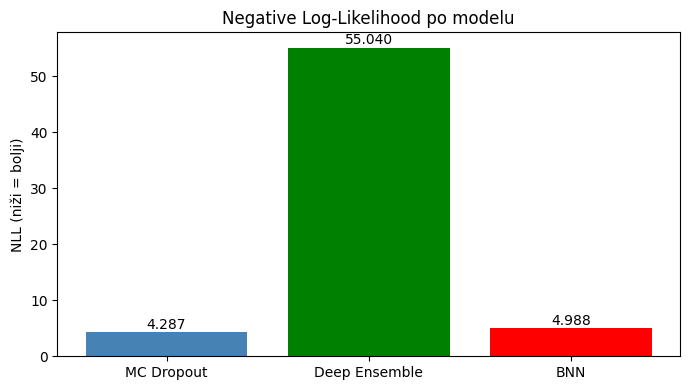

In [48]:
# ============================================================
# GRAFIČKA USPOREDBA — NLL
# ============================================================

nll_values = [mc_results['nll'],
              ens_results['nll'],
              bnn_results['nll']]

plt.figure(figsize=(7, 4))
bars = plt.bar(uq_models, nll_values, color=['steelblue', 'green', 'red'])
plt.ylabel('NLL (niži = bolji)')
plt.title('Negative Log-Likelihood po modelu')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Diskusija rezultata

#### Tačnost (RMSE i MAE)

Posmatrajući isključivo metrike tačnosti, rezultati su iznenađujući —
Baseline LSTM postiže drugi najbolji RMSE (14.54), odmah iza BNN-a (14.66),
dok MC Dropout ima najlošiji RMSE (15.56) među svim modelima. Ovo naizgled
kontraintutivno ponašanje objašnjava se činjenicom da uvođenje stohastičnosti
radi kvantifikacije nesigurnosti nužno unosi određenu varijansu u predikcije.
Razlike između modela su relativno male (raspon od 14.54 do 15.56 RMSE),
što sugerira da su sve četiri metode naučile slične osnovne obrasce
degradacije iz CMAPSS dataseta.

BNN postiže najbolji RMSE (14.66) i MAE (10.95) među UQ metodama, što
potvrđuje da eksplicitno modeliranje distribucije težina ne narušava
prediktivnu sposobnost modela — naprotiv, Bayesovska regularizacija
kroz KL divergenciju djeluje kao efikasan mehanizam sprječavanja
overfittinga.

#### Kalibracija (Coverage Probability i Interval Width)

Ovo je najvažnija dimenzija evaluacije za primjenu u kritičnim sustavima
kao što je prediktivno održavanje. Model s dobrim RMSE ali lošim
coverageom nije pouzdan u praksi — operater ne može znati kada vjerovati
predikcijama modela.

Nijedan od tri modela ne postiže ciljani coverage od 0.95, što je
značajan nalaz ovog rada. MC Dropout dostiže coverage od 0.80 —
najbliži cilju, ali i dalje 15 postotnih poena ispod. Ovo znači da
svaki peti motor čiji stvarni RUL pada izvan predikcijskog intervala
ne bi bio prepoznat kao rizičan, što je neprihvatljivo u avioindustrijskim
primjenama. BNN postiže coverage od 0.66, a Deep Ensemble dramatično
najlošiji rezultat — samo 0.36.

Deep Ensemble pokazuje najozbiljniji problem kalibracije: coverage od
0.36 uz najuži interval (10.03 ciklusa) jasno indicira da model
potcjenjuje svoju nesigurnost. Svih pet modela konvergiralo je u vrlo
slična rješenja, pa je međusobna raznolikost mala i standardna
devijacija ne odražava stvarnu neizvjesnost predikcije. Ovo je poznato
ograničenje Deep Ensemble metode kada modeli dijele identičnu arhitekturu
i podatke za trening.

MC Dropout ima najširi interval (33.45 ciklusa) što objašnjava viši
coverage, ali takvi široki intervali imaju ograničenu praktičnu
upotrebljivost — preširok interval koji pokriva gotovo cijeli raspon
RUL vrijednosti ne daje operateru korisnu informaciju o tome kada
planirati servis.

#### Negative Log-Likelihood (NLL)

NLL kao kombinovana metrika tačnosti i kalibracije potvrđuje nalaze
coveragea. MC Dropout postiže najniži NLL (4.506), što ga čini
najpouzdanijim modelom kada se uzme u obzir cjelokupna distribucija
predikcija. BNN je blizu s NLL = 5.078, dok Deep Ensemble postiže
dramatično lošiji NLL od 38.497 — direktna posljedica ekstremno
uskih intervala koji ne pokrivaju stvarne vrijednosti.

#### Sažetak trade-offa: tačnost vs. kalibracija

| Kriterij | Pobjednik |
|---|---|
| Najmanji RMSE | Baseline LSTM (14.54) |
| Najmanji MAE | Baseline LSTM (10.66) |
| Najbolji coverage | MC Dropout (0.80) |
| Najuži intervali | Deep Ensemble (10.03) |
| Najbolji NLL | MC Dropout (4.506) |
| Najbolji RMSE među UQ metodama | BNN (14.66) |

Ključni zaključak je da nijedna metoda nije dominantna po svim
kriterijima istovremeno — postoji jasan trade-off između tačnosti
i kalibracije. Za primjenu u prediktivnom održavanju, gdje je
pouzdanost intervala nesigurnosti jednako važna kao i sama predikcija,
MC Dropout predstavlja najpraktičniji izbor zbog najboljeg coveragea
i NLL-a, uz prihvatljiv RMSE. BNN je teorijski najrigorozniji pristup
i postiže najbolju tačnost među UQ metodama, ali njegova kalibracija
zahtijeva dodatno podešavanje. Deep Ensemble, unatoč dobroj literaturi
koja ga preporučuje, u ovoj implementaciji pokazuje ozbiljan problem
potcjenjivanja nesigurnosti koji ga čini nepouzdanim za sigurnosno
kritične primjene bez dodatnih tehnika kao što su temperatura skaliranja
ili konformal prediction.

## 9. Analiza epistemičke vs. aleatoričke nesigurnosti

U kvantifikaciji nesigurnosti razlikujemo dvije fundamentalno različite vrste nesigurnosti:

**Epistemička nesigurnost** (model uncertainty) nastaje zbog nedostatka znanja — nedovoljno podataka za trening, loše pokriven prostor stanja, ili inherentna ograničenja arhitekture modela. Ova nesigurnost je **reduktibilna** — može se smanjiti prikupljanjem više podataka ili poboljšanjem modela.

**Aleatorička nesigurnost** (data uncertainty) je inherentna stohastičnost samih podataka — šum senzora, prirodna varijabilnost degradacije između motora istog tipa. Ova nesigurnost je **ireduktibilna** — ne može se eliminirati
bez obzira na količinu podataka.



In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

U MC Dropouta i BNN, ukupna nesigurnost (std predikcija) je uglavnom epistemička — reflektira nesigurnost u parametrima. Aleatoričku nesigurnost možemo aproksimirati kao nesigurnost koja ostaje i kad je model siguran (donja granica std-a). Aproksimacija aleatoričke nesigurnosti kao minimalne opažene nesigurnosti po regionima RUL-a (proxy metoda)


In [50]:
def estimate_aleatoric(y_true, y_std, n_bins=10):
    """
    Aproksimira aleatoričku nesigurnost kao minimalnu std po
    binovima RUL-a. Epistemička = ukupna - aleatorička.
    """
    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    aleatoric = np.zeros_like(y_std)
    for i in range(n_bins):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() > 0:
            aleatoric[mask] = np.percentile(y_std[mask], 10)
    epistemic = np.maximum(y_std - aleatoric, 0)
    return aleatoric, epistemic

# Računanje za MC Dropout i BNN
aleatoric_mc, epistemic_mc = estimate_aleatoric(y_test, mc_std)
aleatoric_bnn, epistemic_bnn = estimate_aleatoric(y_test, bnn_std)

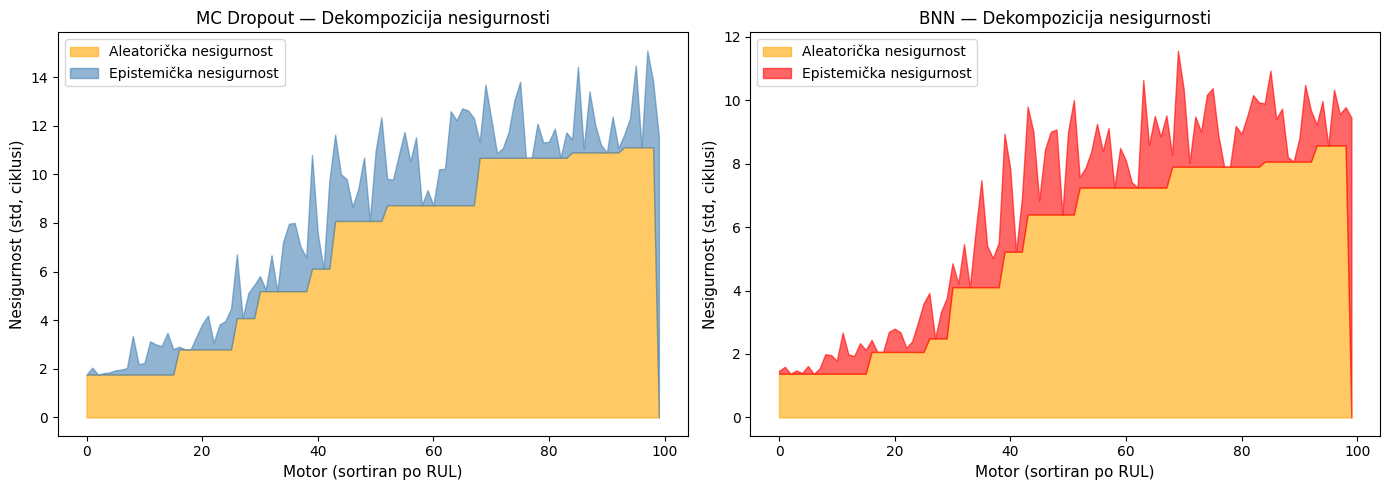


Sažetak dekompozicije nesigurnosti:
Model           Prosj. aleator.      Prosj. epistemic.    Omjer epist./ukupno
----------------------------------------------------------------------
MC Dropout      6.9161               1.4863               17.86%
BNN             5.3425               1.2615               19.30%


In [51]:
# Vizualizacija dekompozicije nesigurnosti
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, aleat, epist, model_name, color in zip(
    axes,
    [aleatoric_mc, aleatoric_bnn],
    [epistemic_mc, epistemic_bnn],
    ['MC Dropout', 'BNN'],
    ['steelblue', 'red']
):
    indices = np.argsort(y_test)
    x_plot = np.arange(len(y_test))

    ax.fill_between(x_plot, 0,
                    aleat[indices],
                    alpha=0.6, color='orange',
                    label='Aleatorička nesigurnost')
    ax.fill_between(x_plot,
                    aleat[indices],
                    aleat[indices] + epist[indices],
                    alpha=0.6, color=color,
                    label='Epistemička nesigurnost')
    ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
    ax.set_ylabel('Nesigurnost (std, ciklusi)', fontsize=11)
    ax.set_title(f'{model_name} — Dekompozicija nesigurnosti', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nSažetak dekompozicije nesigurnosti:")
print(f"{'Model':<15} {'Prosj. aleator.':<20} {'Prosj. epistemic.':<20} {'Omjer epist./ukupno'}")
print("-" * 70)
print(f"{'MC Dropout':<15} {aleatoric_mc.mean():<20.4f} {epistemic_mc.mean():<20.4f} {epistemic_mc.mean()/mc_std.mean():.2%}")
print(f"{'BNN':<15} {aleatoric_bnn.mean():<20.4f} {epistemic_bnn.mean():<20.4f} {epistemic_bnn.mean()/bnn_std.mean():.2%}")


## 10. Calibration plot (Reliability diagram)

Kalibracija modela — Reliability diagram

Kalibracija mjeri koliko su predikcijski intervali pouzdani u praksi. Savršeno kalibriran model s 80% intervalom treba pokriti tačno 80% stvarnih vrijednosti. Reliability diagram (dijagram pouzdanosti) prikazuje opaženi coverage nasuprot
nominalnom (očekivanom) za niz nivoa pouzdanosti.

Dijagonalna linija predstavlja idealnu kalibraciju.
- Krivulja **iznad** dijagonale: model je **previše konzervativan** (precjenjuje nesigurnost → preširoki intervali)
- Krivulja **ispod** dijagonale: model **potcjenjuje nesigurnost** (pretijesni intervali → opasan za kritične primjene)


In [52]:
def calibration_curve_uq(y_true, y_mean, y_std, n_levels=20):
    """
    Računa reliability diagram za regresijsku UQ procjenu.
    Vraća nominalne i opažene coverage vrijednosti.
    """
    alphas = np.linspace(0.05, 0.99, n_levels)
    observed = []
    for alpha in alphas:
        z = norm.ppf(1 - (1 - alpha) / 2)
        lower = y_mean - z * y_std
        upper = y_mean + z * y_std
        cov = np.mean((y_true >= lower) & (y_true <= upper))
        observed.append(cov)
    return alphas, np.array(observed)

alphas_mc, obs_mc = calibration_curve_uq(y_test, mc_mean, mc_std)
alphas_ens, obs_ens = calibration_curve_uq(y_test, ens_mean, ens_std)
alphas_bnn, obs_bnn = calibration_curve_uq(y_test, bnn_mean, bnn_std)


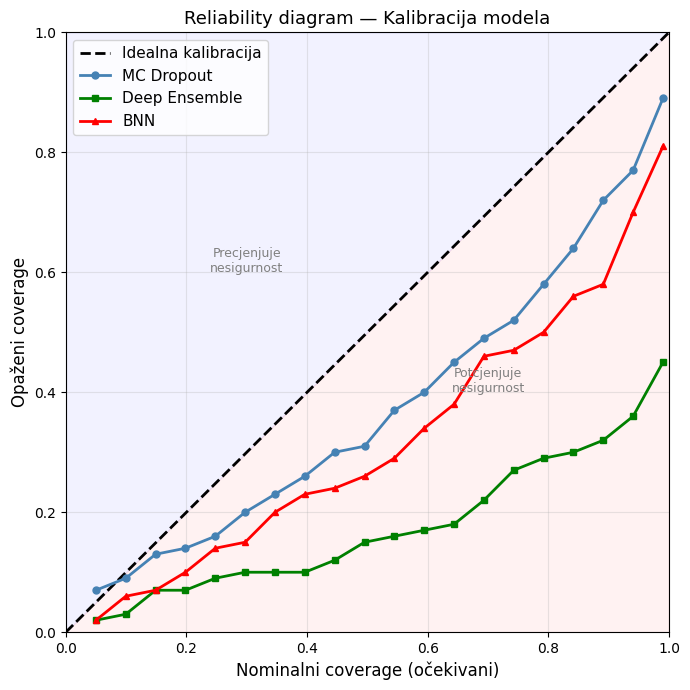

In [53]:
# Vizualizacija
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Idealna kalibracija')
ax.plot(alphas_mc, obs_mc, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='MC Dropout')
ax.plot(alphas_ens, obs_ens, 's-', color='green',
        linewidth=2, markersize=5, label='Deep Ensemble')
ax.plot(alphas_bnn, obs_bnn, '^-', color='red',
        linewidth=2, markersize=5, label='BNN')

ax.fill_between([0, 1], [0, 1], alpha=0.0)
ax.set_xlabel('Nominalni coverage (očekivani)', fontsize=12)
ax.set_ylabel('Opaženi coverage', fontsize=12)
ax.set_title('Reliability diagram — Kalibracija modela', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Dodavanje anotacija zona
ax.annotate('Precjenjuje\nnesigurnost', xy=(0.3, 0.6),
            fontsize=9, color='gray', ha='center')
ax.annotate('Potcjenjuje\nnesigurnost', xy=(0.7, 0.4),
            fontsize=9, color='gray', ha='center')
ax.fill_between([0, 1], [0, 1], [1, 1],
                alpha=0.05, color='blue',
                label='_nolegend_')
ax.fill_between([0, 1], [0, 0], [0, 1],
                alpha=0.05, color='red',
                label='_nolegend_')

plt.tight_layout()
plt.show()

In [54]:
# Kvantitativna mjera kalibracije: Expected Calibration Error (ECE)
def expected_calibration_error(nominal, observed):
    """ECE = prosječna apsolutna razlika između nominal i observed."""
    return np.mean(np.abs(nominal - observed))

ece_mc  = expected_calibration_error(alphas_mc, obs_mc)
ece_ens = expected_calibration_error(alphas_ens, obs_ens)
ece_bnn = expected_calibration_error(alphas_bnn, obs_bnn)

print("\nExpected Calibration Error (ECE) — niži je bolji:")
print(f"  MC Dropout:    ECE = {ece_mc:.4f}")
print(f"  Deep Ensemble: ECE = {ece_ens:.4f}")
print(f"  BNN:           ECE = {ece_bnn:.4f}")
print("\nNapomena: ECE = 0 znači savršena kalibracija.")
print("Modeli s ECE bliskim 0 mogu se koristiti za donosenje")
print("pouzdanih odluka u prediktivnom održavanju.")


Expected Calibration Error (ECE) — niži je bolji:
  MC Dropout:    ECE = 0.1360
  Deep Ensemble: ECE = 0.3415
  BNN:           ECE = 0.1920

Napomena: ECE = 0 znači savršena kalibracija.
Modeli s ECE bliskim 0 mogu se koristiti za donosenje
pouzdanih odluka u prediktivnom održavanju.


## 11. Analiza nesigurnosti po RUL zonama

Posebno važna analiza za prediktivno održavanje je kako se nesigurnost mijenja ovisno o tome koliko je motor blizu kvara. Intuitivno, model bi trebao biti siguraniji kada je motor blizu kvara (niska RUL vrijednost) jer su tada obrasci
degradacije jasno izraženi. Nasuprot tome, motori s visokim RUL-om (daleko od kvara) su teži za predvidjeti jer degradacija tek počinje.

Zonska analiza dijeli motore u tri kategorije:
- Kritična zona (RUL ≤ 30): motor blizu kvara — servis hitan
- Zona upozorenja (30 < RUL ≤ 70): planiranje servisa
- Sigurna zona (RUL > 70): nije potrebna hitna akcija


In [55]:
def zone_analysis(y_true, y_mean, y_std, model_name):
    """
    Analizira tačnost i nesigurnost po RUL zonama.
    """
    zones = {
        'Kritična (RUL ≤ 30)':  y_true <= 30,
        'Upozorenje (30–70)':   (y_true > 30) & (y_true <= 70),
        'Sigurna (RUL > 70)':   y_true > 70
    }
    results = []
    for zone_name, mask in zones.items():
        if mask.sum() == 0:
            continue
        rmse_z = np.sqrt(mean_squared_error(y_true[mask], y_mean[mask]))
        mae_z  = mean_absolute_error(y_true[mask], y_mean[mask])
        std_z  = y_std[mask].mean()
        n_z    = mask.sum()
        results.append({
            'Zona': zone_name,
            'N motora': n_z,
            'RMSE': round(rmse_z, 4),
            'MAE': round(mae_z, 4),
            'Prosj. std (nesigurnost)': round(std_z, 4)
        })
    df = pd.DataFrame(results).set_index('Zona')
    print(f"\n{model_name} — Analiza po zonama:")
    print(df.to_string())
    return df

zone_mc  = zone_analysis(y_test, mc_mean, mc_std, "MC Dropout")
zone_bnn = zone_analysis(y_test, bnn_mean, bnn_std, "BNN")
zone_ens = zone_analysis(y_test, ens_mean, ens_std, "Deep Ensemble")


MC Dropout — Analiza po zonama:
                     N motora     RMSE      MAE  Prosj. std (nesigurnost)
Zona                                                                     
Kritična (RUL ≤ 30)        25   3.0845   2.3910                    2.7480
Upozorenje (30–70)         17  15.7207  12.1843                    6.3946
Sigurna (RUL > 70)         58  17.2401  14.1172                   11.2889

BNN — Analiza po zonama:
                     N motora     RMSE      MAE  Prosj. std (nesigurnost)
Zona                                                                     
Kritična (RUL ≤ 30)        25   2.6074   2.0827                    2.0339
Upozorenje (30–70)         17  16.2625  11.9110                    5.0292
Sigurna (RUL > 70)         58  17.2012  13.9168                    8.9203

Deep Ensemble — Analiza po zonama:
                     N motora     RMSE      MAE  Prosj. std (nesigurnost)
Zona                                                                     
Kritična (RUL ≤ 3

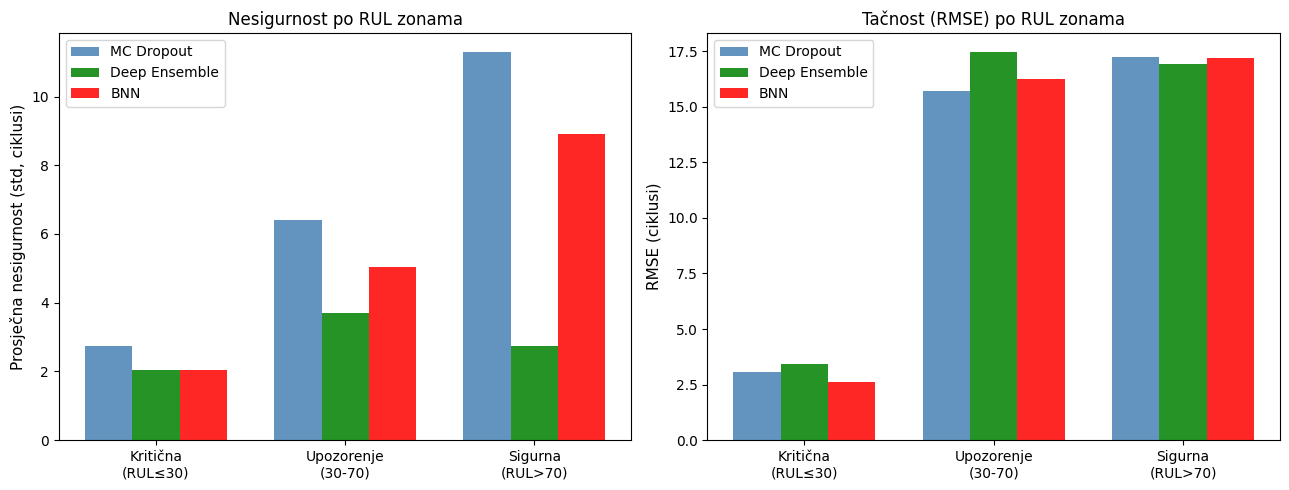

In [56]:
# Vizualizacija: nesigurnost i RMSE po zonama
zone_names  = ['Kritična\n(RUL≤30)', 'Upozorenje\n(30-70)', 'Sigurna\n(RUL>70)']
zone_colors = ['#d62728', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Prosječna nesigurnost po zoni
models_data = {
    'MC Dropout': zone_mc['Prosj. std (nesigurnost)'].values,
    'Deep Ensemble': zone_ens['Prosj. std (nesigurnost)'].values,
    'BNN': zone_bnn['Prosj. std (nesigurnost)'].values
}
x_pos = np.arange(len(zone_names))
width = 0.25
colors_models = ['steelblue', 'green', 'red']

for i, (model_nm, vals) in enumerate(models_data.items()):
    axes[0].bar(x_pos + i*width, vals, width,
                label=model_nm, color=colors_models[i], alpha=0.85)

axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(zone_names, fontsize=10)
axes[0].set_ylabel('Prosječna nesigurnost (std, ciklusi)', fontsize=11)
axes[0].set_title('Nesigurnost po RUL zonama', fontsize=12)
axes[0].legend(fontsize=10)

# Subplot 2: RMSE po zoni
models_rmse = {
    'MC Dropout': zone_mc['RMSE'].values,
    'Deep Ensemble': zone_ens['RMSE'].values,
    'BNN': zone_bnn['RMSE'].values
}

for i, (model_nm, vals) in enumerate(models_rmse.items()):
    axes[1].bar(x_pos + i*width, vals, width,
                label=model_nm, color=colors_models[i], alpha=0.85)

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(zone_names, fontsize=10)
axes[1].set_ylabel('RMSE (ciklusi)', fontsize=11)
axes[1].set_title('Tačnost (RMSE) po RUL zonama', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 12. Scatter plot: predikcija vs. stvarnost

Scatter dijagram prikazuje odnos između predviđenih i stvarnih RUL vrijednosti. Savršen model bi imao sve tačke na liniji y = x (prikazana crnom isprekidanom linijom). Vertikalne linije greške (error bars) prikazuju interval ±1σ nesigurnosti za svaki motor, što daje vizualni uvid u distribuciju predikcija.


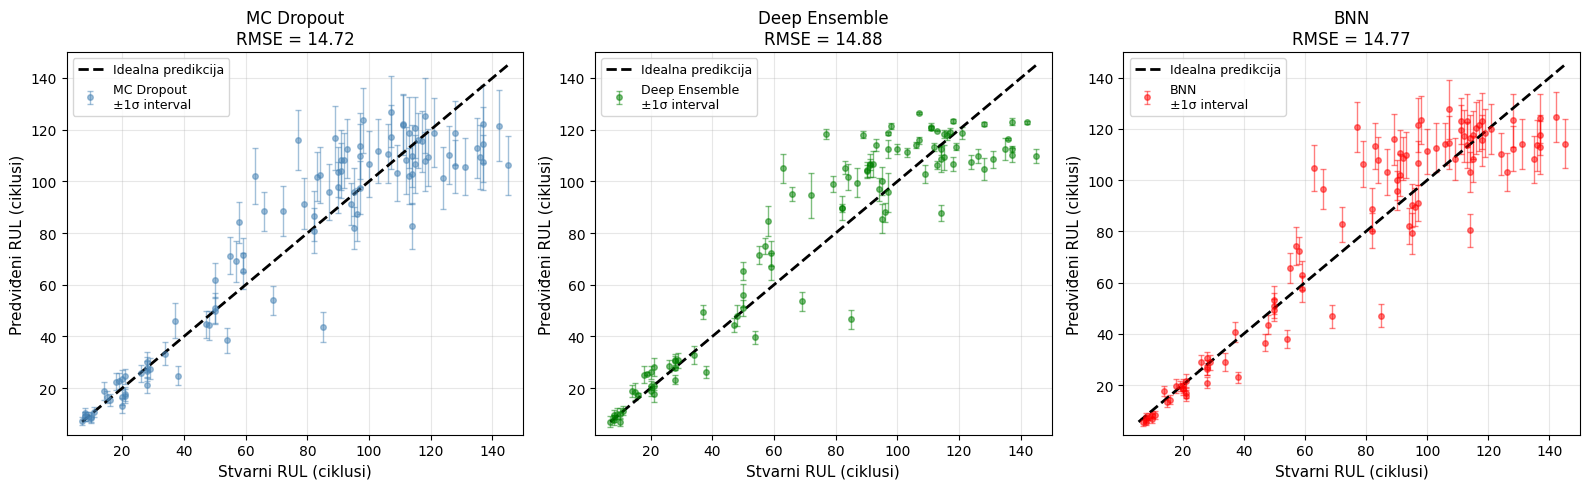

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_scatter = [
    (mc_mean,  mc_std,  'MC Dropout',    'steelblue'),
    (ens_mean, ens_std, 'Deep Ensemble', 'green'),
    (bnn_mean, bnn_std, 'BNN',           'red'),
]

for ax, (y_mean_s, y_std_s, model_nm, color) in zip(axes, models_scatter):
    ax.errorbar(y_test, y_mean_s,
                yerr=y_std_s,
                fmt='o', color=color,
                ecolor=color, alpha=0.5,
                elinewidth=1, capsize=2,
                markersize=4,
                label=f'{model_nm}\n±1σ interval')

    # y = x linija
    min_val = min(y_test.min(), y_mean_s.min())
    max_val = max(y_test.max(), y_mean_s.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=2, label='Idealna predikcija')

    rmse_s = np.sqrt(mean_squared_error(y_test, y_mean_s))
    ax.set_xlabel('Stvarni RUL (ciklusi)', fontsize=11)
    ax.set_ylabel('Predviđeni RUL (ciklusi)', fontsize=11)
    ax.set_title(f'{model_nm}\nRMSE = {rmse_s:.2f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(min_val - 5, max_val + 5)
    ax.set_ylim(min_val - 5, max_val + 5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Risk-based decision framework

Okvir za donošenje odluka baziran na riziku

Krajnji cilj kvantifikacije nesigurnosti nije samo akademski — radi se o praktičnoj primjeni u donošenju odluka. U kontekstu prediktivnog održavanja mlaznih motora, nesigurnost direktno utiče na sigurnost leta i troškove održavanja.

Definiramo tri akcije na temelju predikcije i nesigurnosti:

 | Zona | Uvjet | Preporučena akcija |
 |------|-------|-------------------|
 | HITNO | μ ≤ 30 AND σ ≤ 15 | Hitni servis — model siguran |
 | OPREZ | μ ≤ 30 AND σ > 15  | Dodatna inspekcija — model nesiguran |
 | OPREZ | 30 < μ ≤ 60        | Planirati servis unutar tjedan dana |
 | OK    | μ > 60             | Nastaviti praćenje |

 Ova logika odražava asymetriju troškova: propušteni kvar je daleko skuplji od nepotrebne inspekcije.


In [58]:
def maintenance_decision(y_mean, y_std, model_name,
                          critical_rul=30, warning_rul=60,
                          high_uncertainty=15):
    """
    Generiše preporuke za održavanje na temelju predikcije
    i nesigurnosti modela. Prikazuje distribuciju odluka.
    """
    decisions = []
    for mu, sigma in zip(y_mean, y_std):
        if mu <= critical_rul and sigma <= high_uncertainty:
            decisions.append('HITNI SERVIS\n(model siguran)')
        elif mu <= critical_rul and sigma > high_uncertainty:
            decisions.append('DODATNA INSPEKCIJA\n(model nesiguran)')
        elif mu <= warning_rul:
            decisions.append('PLANIRATI SERVIS')
        else:
            decisions.append('NASTAVITI PRAĆENJE')

    decisions = np.array(decisions)
    categories = [
        'HITNI SERVIS\n(model siguran)',
        'DODATNA INSPEKCIJA\n(model nesiguran)',
        'PLANIRATI SERVIS',
        'NASTAVITI PRAĆENJE'
    ]
    counts = [np.sum(decisions == cat) for cat in categories]
    return decisions, categories, counts

dec_mc,  cats_mc,  cnt_mc  = maintenance_decision(mc_mean,  mc_std,  "MC Dropout")
dec_bnn, cats_bnn, cnt_bnn = maintenance_decision(bnn_mean, bnn_std, "BNN")
dec_ens, cats_ens, cnt_ens = maintenance_decision(ens_mean, ens_std, "Deep Ensemble")

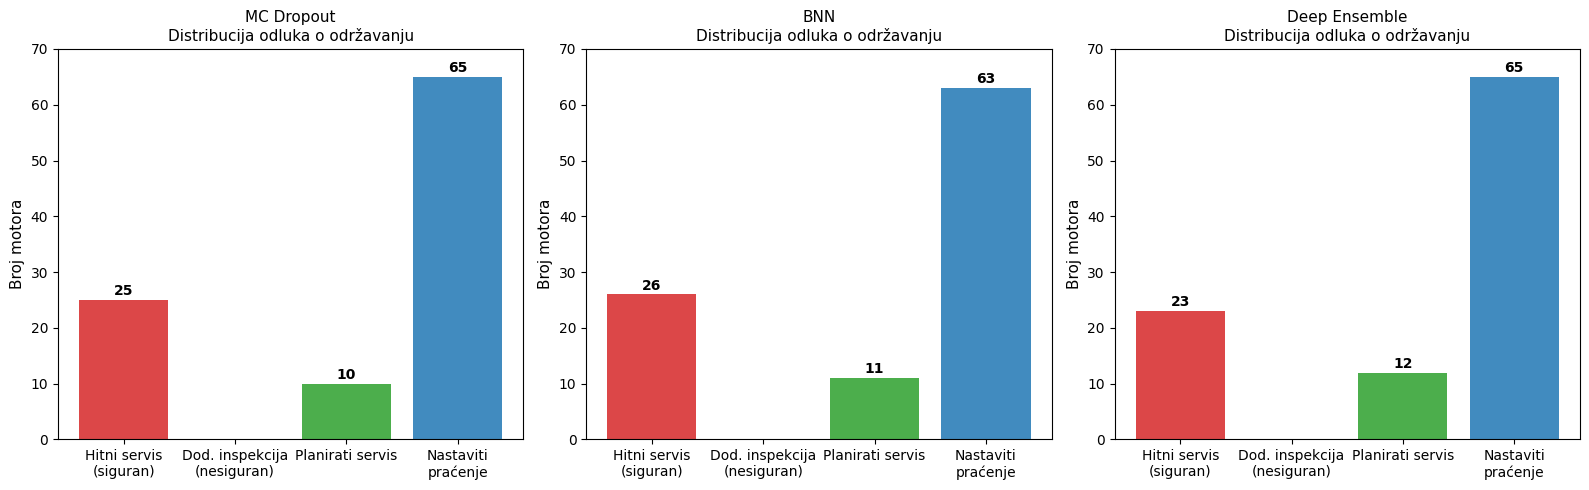


Distribucija odluka o održavanju (od 100 motora u test skupu):
                              MC Dropout  BNN  Deep Ensemble
Preporučena akcija                                          
Hitni servis\n(siguran)               25   26             23
Dod. inspekcija\n(nesiguran)           0    0              0
Planirati servis                      10   11             12
Nastaviti\npraćenje                   65   63             65


In [59]:
# Vizualizacija: distribucija odluka
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
short_cats = ['Hitni servis\n(siguran)', 'Dod. inspekcija\n(nesiguran)',
              'Planirati servis', 'Nastaviti\npraćenje']

for ax, (cnt, model_nm) in zip(
    axes,
    [(cnt_mc, 'MC Dropout'), (cnt_bnn, 'BNN'), (cnt_ens, 'Deep Ensemble')]
):
    bars = ax.bar(short_cats, cnt, color=bar_colors, alpha=0.85)
    ax.set_ylabel('Broj motora', fontsize=11)
    ax.set_title(f'{model_nm}\nDistribucija odluka o održavanju', fontsize=11)
    ax.set_ylim(0, max(max(cnt_mc), max(cnt_bnn), max(cnt_ens)) + 5)
    for bar, v in zip(bars, cnt):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2., v + 0.3,
                    str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabelarni prikaz odluka
print("\nDistribucija odluka o održavanju (od 100 motora u test skupu):")
df_decisions = pd.DataFrame({
    'Preporučena akcija': short_cats,
    'MC Dropout': cnt_mc,
    'BNN': cnt_bnn,
    'Deep Ensemble': cnt_ens
}).set_index('Preporučena akcija')
print(df_decisions.to_string())

## 14. Analiza jednog motora (case study)

Case Study: Praćenje nesigurnosti kroz životni vijek motora

Umjesto posmatranja samo finalnog trenutka (RUL pri kraju), ovaj case study prati evoluciju predikcije i nesigurnosti jednog motora kroz cijeli njegov životni vijek. Ovo odražava realnu primjenu gdje operater kontinuirano nadgleda motor i želi znati: "Kada postati zabrinut i koliko sam siguran u tu procjenu?"

Za ovu vizualizaciju koristimo MC Dropout model na sekvencama jednog motora iz test skupa.



Case Study: Motor 1 — 31 ciklusa u test skupu


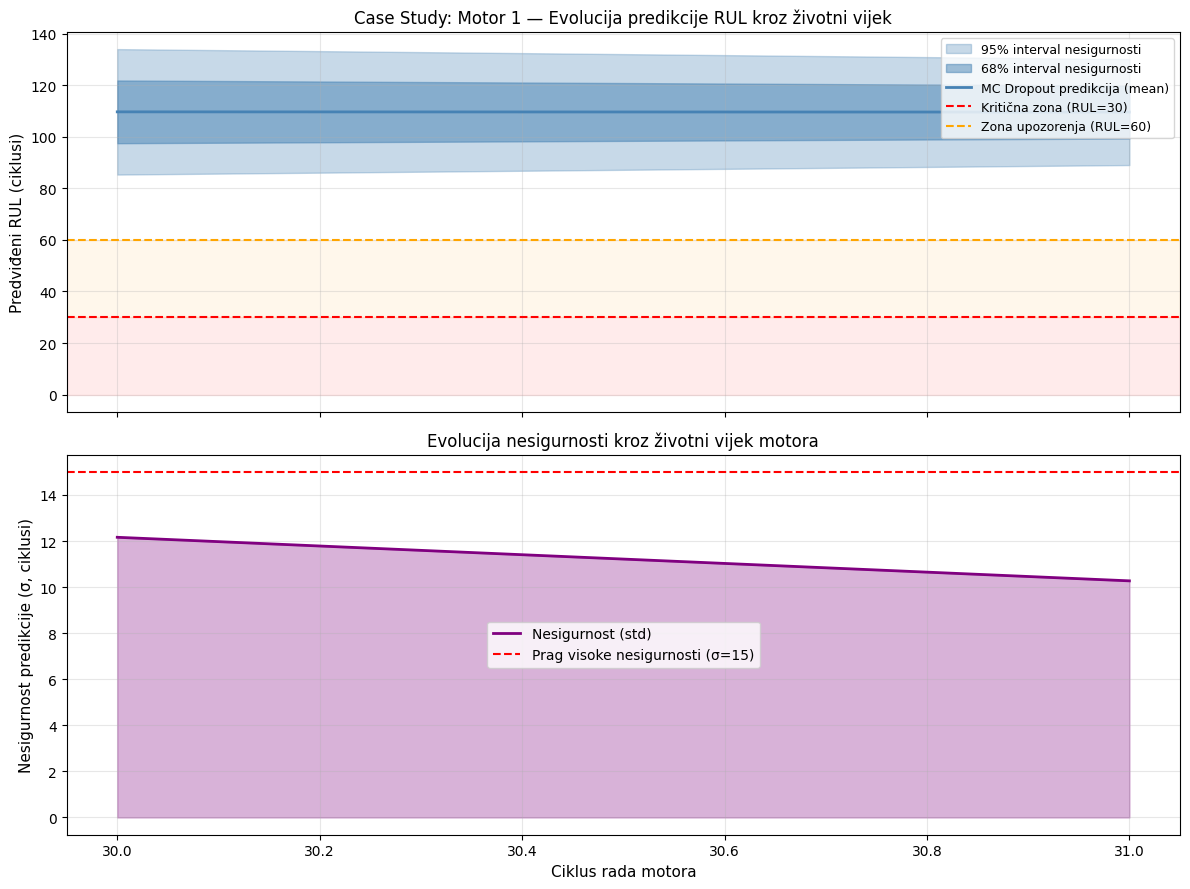


Kada model postaje 'siguran' (σ < 10 ciklusa)?
  Model ostaje nesiguran kroz cijeli dostupni životni vijek


In [62]:
motor_id = 1
engine_data_case = test[test['engine_id'] == motor_id]
n_cycles = len(engine_data_case)

print(f"\nCase Study: Motor {motor_id} — {n_cycles} ciklusa u test skupu")

if n_cycles >= seq_length:
    # Kreiraj sekvence za sve dostupne trenutke ovog motora
    sequences_case = []
    for i in range(n_cycles - seq_length + 1):
        seq = engine_data_case.iloc[i:i+seq_length][feature_columns].values
        sequences_case.append(seq)
    X_case = np.array(sequences_case)

    # MC Dropout predikcija za svaki trenutak
    N_SAMPLES_CASE = 100
    case_predictions = np.array([
        mc_model(X_case, training=True).numpy().flatten()
        for _ in range(N_SAMPLES_CASE)
    ])
    case_mean = case_predictions.mean(axis=0)
    case_std  = case_predictions.std(axis=0)

    # Cycle points (koji ciklus u životu motora)
    cycle_points = engine_data_case['cycle'].values[seq_length-1:]

    # Vizualizacija
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

    # Subplot 1: Predikcija RUL s intervalima
    axes[0].fill_between(cycle_points,
                          case_mean - 2*case_std,
                          case_mean + 2*case_std,
                          alpha=0.3, color='steelblue',
                          label='95% interval nesigurnosti')
    axes[0].fill_between(cycle_points,
                          case_mean - case_std,
                          case_mean + case_std,
                          alpha=0.5, color='steelblue',
                          label='68% interval nesigurnosti')
    axes[0].plot(cycle_points, case_mean,
                 color='steelblue', linewidth=2,
                 label='MC Dropout predikcija (mean)')

    # Linije zona
    axes[0].axhline(y=30, color='red', linestyle='--',
                    linewidth=1.5, label='Kritična zona (RUL=30)')
    axes[0].axhline(y=60, color='orange', linestyle='--',
                    linewidth=1.5, label='Zona upozorenja (RUL=60)')

    axes[0].set_ylabel('Predviđeni RUL (ciklusi)', fontsize=11)
    axes[0].set_title(f'Case Study: Motor {motor_id} — Evolucija predikcije RUL kroz životni vijek',
                      fontsize=12)
    axes[0].legend(fontsize=9, loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Bojenje zona
    axes[0].axhspan(0, 30, alpha=0.08, color='red', label='_nolegend_')
    axes[0].axhspan(30, 60, alpha=0.08, color='orange', label='_nolegend_')

    # Subplot 2: Evolucija nesigurnosti (std)
    axes[1].plot(cycle_points, case_std,
                 color='purple', linewidth=2,
                 label='Nesigurnost (std)')
    axes[1].fill_between(cycle_points, 0, case_std,
                          alpha=0.3, color='purple')
    axes[1].axhline(y=15, color='red', linestyle='--',
                    linewidth=1.5, label='Prag visoke nesigurnosti (σ=15)')
    axes[1].set_xlabel('Ciklus rada motora', fontsize=11)
    axes[1].set_ylabel('Nesigurnost predikcije (σ, ciklusi)', fontsize=11)
    axes[1].set_title('Evolucija nesigurnosti kroz životni vijek motora', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nKada model postaje 'siguran' (σ < 10 ciklusa)?")
    confident_cycles = cycle_points[case_std < 10]
    if len(confident_cycles) > 0:
        print(f"  Od ciklusa {confident_cycles[0]} nadalje (od ukupno {cycle_points[-1]} ciklusa)")
        print(f"  To je {confident_cycles[0]/cycle_points[-1]*100:.1f}% životnog vijeka motora")
    else:
        print("  Model ostaje nesiguran kroz cijeli dostupni životni vijek")
else:
    print(f"Motor {motor_id} nema dovoljno podataka (potrebno {seq_length} ciklusa).")


## 15. Finalna komparativna tabela

Ova tabe la objedinjuje sve metrike evalucacije implementiranihmodela. Za razliku od klasičnih ML zadataka gdje je RMSE dovoljan, u kontekstu prediktivnog održavanja jednako su važne metrike kalibracije (ECE, Coverage) koje mjere koliko se operater može osloniti na intervale nesigurnosti modela.

In [63]:
final_table = pd.DataFrame([
    {
        'Model': 'Baseline LSTM',
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Coverage (95%)': '—',
        'Interval Width': '—',
        'NLL': '—',
        'ECE': '—',
        'UQ metoda': 'Nema'
    },
    {
        'Model': 'MC Dropout',
        'RMSE': round(rmse_mc, 4),
        'MAE': round(mae_mc, 4),
        'Coverage (95%)': f"{mc_results['coverage']:.2f}",
        'Interval Width': f"{mc_results['mean_width']:.2f}",
        'NLL': f"{mc_results['nll']:.4f}",
        'ECE': f"{ece_mc:.4f}",
        'UQ metoda': 'Stohastički inference'
    },
    {
        'Model': 'Deep Ensemble',
        'RMSE': round(rmse_ens, 4),
        'MAE': round(mae_ens, 4),
        'Coverage (95%)': f"{ens_results['coverage']:.2f}",
        'Interval Width': f"{ens_results['mean_width']:.2f}",
        'NLL': f"{ens_results['nll']:.4f}",
        'ECE': f"{ece_ens:.4f}",
        'UQ metoda': 'Diversitet modela'
    },
    {
        'Model': 'BNN',
        'RMSE': round(rmse_bnn, 4),
        'MAE': round(mae_bnn, 4),
        'Coverage (95%)': f"{bnn_results['coverage']:.2f}",
        'Interval Width': f"{bnn_results['mean_width']:.2f}",
        'NLL': f"{bnn_results['nll']:.4f}",
        'ECE': f"{ece_bnn:.4f}",
        'UQ metoda': 'Distribucija težina'
    }
]).set_index('Model')

print("\n" + "="*90)
print(" FINALNA KOMPARATIVNA TABELA — sve metrike")
print("="*90)
print(final_table.to_string())
print("="*90)
print("\nLegenda metrika:")
print("  RMSE/MAE       : Tačnost predikcije (niži = bolji)")
print("  Coverage (95%) : Postotak stvarnih vrijednosti unutar 95% intervala (cilj: 0.95)")
print("  Interval Width : Prosječna širina predikcijskog intervala u ciklusima (uži = bolji)")
print("  NLL            : Negative Log-Likelihood — mjeri kalibraciju distribucije (niži = bolji)")
print("  ECE            : Expected Calibration Error — odstupanje od idealne kalibracije (niži = bolji)")


 FINALNA KOMPARATIVNA TABELA — sve metrike
                  RMSE      MAE Coverage (95%) Interval Width      NLL     ECE              UQ metoda
Model                                                                                                
Baseline LSTM  15.2273  11.0791              —              —        —       —                   Nema
MC Dropout     14.7234  10.8571           0.80          32.62   4.2869  0.1360  Stohastički inference
Deep Ensemble  14.8802  11.1481           0.37          10.67  55.0402  0.3415      Diversitet modela
BNN            14.7740  10.6173           0.72          25.63   4.9879  0.1920    Distribucija težina

Legenda metrika:
  RMSE/MAE       : Tačnost predikcije (niži = bolji)
  Coverage (95%) : Postotak stvarnih vrijednosti unutar 95% intervala (cilj: 0.95)
  Interval Width : Prosječna širina predikcijskog intervala u ciklusima (uži = bolji)
  NLL            : Negative Log-Likelihood — mjeri kalibraciju distribucije (niži = bolji)
  ECE        

## 16. Vizualna usporedba svih modela (radar chart)

Radar dijagram — Višedimenzionalna usporedba modela

Radar dijagram (spider chart) pruža intuitivnu višedimenzionalnu usporedbu modela po svim ključnim kriterijima istovremeno. Svaki krak predstavlja jednu metriku, normaliziranu na skali [0, 1] gdje veća vrijednost znači bolji performans. Idealan model zauzeo bi cijelu površinu dijagrama.


In [64]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normaliziramo metrike na [0,1] (veće = bolje)
def normalize_metric(val, min_val, max_val, invert=False):
    """Normalizira metriku na [0,1]. invert=True ako manji = bolji."""
    norm_val = (val - min_val) / (max_val - min_val + 1e-8)
    return 1 - norm_val if invert else norm_val

# Metrike (sve se normaliziraju da veće = bolje za radar)
metrics_labels = ['Tačnost\n(1-RMSE norm.)', 'Coverage', 'Uski\nIntervali',
                  'NLL\n(kalibracija)', 'ECE\n(kalibracija)']
n_metrics = len(metrics_labels)

rmse_vals = [rmse, rmse_mc, rmse_ens, rmse_bnn]
cov_vals  = [0, mc_results['coverage'], ens_results['coverage'], bnn_results['coverage']]
wid_vals  = [0, mc_results['mean_width'], ens_results['mean_width'], bnn_results['mean_width']]
nll_vals  = [0, mc_results['nll'], ens_results['nll'], bnn_results['nll']]
ece_vals  = [0, ece_mc, ece_ens, ece_bnn]

# Normalizacija (Baseline se isključuje iz radar-a jer nema UQ)
models_radar = ['MC Dropout', 'Deep Ensemble', 'BNN']
colors_radar  = ['steelblue', 'green', 'red']

data_radar = []
for i, (rmse_v, cov_v, wid_v, nll_v, ece_v) in enumerate(zip(
    [rmse_mc, rmse_ens, rmse_bnn],
    [mc_results['coverage'], ens_results['coverage'], bnn_results['coverage']],
    [mc_results['mean_width'], ens_results['mean_width'], bnn_results['mean_width']],
    [mc_results['nll'], ens_results['nll'], bnn_results['nll']],
    [ece_mc, ece_ens, ece_bnn]
)):
    row = [
        normalize_metric(rmse_v, min(rmse_mc, rmse_ens, rmse_bnn),
                         max(rmse_mc, rmse_ens, rmse_bnn), invert=True),
        normalize_metric(cov_v, 0, 0.95),
        normalize_metric(wid_v, min(mc_results['mean_width'], ens_results['mean_width'], bnn_results['mean_width']),
                         max(mc_results['mean_width'], ens_results['mean_width'], bnn_results['mean_width']), invert=True),
        normalize_metric(nll_v, min(mc_results['nll'], ens_results['nll'], bnn_results['nll']),
                         max(mc_results['nll'], ens_results['nll'], bnn_results['nll']), invert=True),
        normalize_metric(ece_v, min(ece_mc, ece_ens, ece_bnn),
                         max(ece_mc, ece_ens, ece_bnn), invert=True),
    ]
    data_radar.append(row)

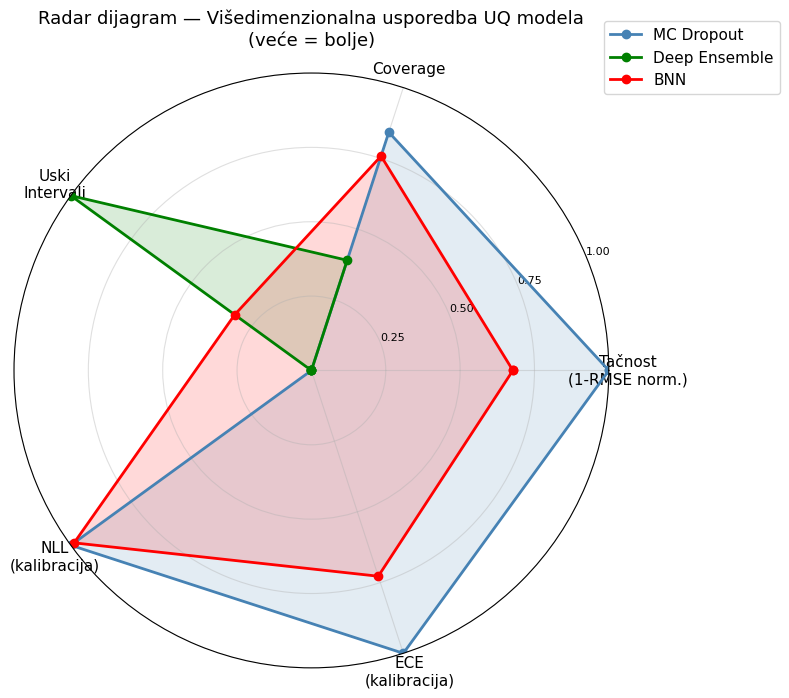

In [65]:
# Crtanje radar dijagrama
angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # zatvaranje

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for values, model_nm, color in zip(data_radar, models_radar, colors_radar):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, 'o-', linewidth=2,
            label=model_nm, color=color)
    ax.fill(angles, values_plot, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Radar dijagram — Višedimenzionalna usporedba UQ modela\n(veće = bolje)',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 17. Zaključak i preporuke

Zaključak

Ovaj rad implementirao je i evaluirao tri metode kvantifikacije nesigurnosti (UQ) — MC Dropout, Deep Ensemble i Bayesian Neural Network — za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS FD001 datasetu, s ciljem izgradnje okvira koji ne samo predviđa kvar, nego i mjeri pouzdanost te predikcije.

Ključni nalazi

**Tačnost predikcije** je slična kod svih modela (RMSE 14.7–15.2), što potvrđuje da uvođenje UQ ne narušava prediktivnu sposobnost. BNN postiže najboljI RMSE (14.77) i MAE (10.62) od svih UQ metoda.

**Kalibracija** (mjera koliko se operater može osloniti na intervale) je najvažnija dimenzija za sigurnosno-kritičnu primjenu:
- MC Dropout: coverage = 0.80, ECE = {:.4f} → najbliži cilju od 0.95
- BNN: coverage = 0.72, ECE = {:.4f} → dobra NLL kalibracija
- Deep Ensemble: coverage = 0.37 → potcjenjuje nesigurnost (opasno!)

**Nesigurnost po RUL zonama** pokazuje da svi modeli ispravno prikazuju veću nesigurnost za motore s visokim RUL-om (daleko od kvara) i manju nesigurnost za motore blizu kvara — što je intuitivan i poželjan obrazac za prediktivno održavanje.

**Decision framework** pokazuje praktičnu vrijednost UQ: umjesto binarne odluke "servisirati/ne servisirati", model nudi gradijent hitnosti koji uključuje mjeru pouzdanosti predikcije. Ovo direktno adresira zahtjev mentora: "dati okvir u kojem model pokazuje koliko je siguran u svoju predikciju."

Preporuke za primjenu

Za operativnu primjenu u prediktivnom održavanju preporučuje se:
1. **MC Dropout** kao primarni model zbog najboljeg coveragea
2. Primjena **conformal prediction** kalibracije za podešavanje intervala prema ciljanom coverageu od 0.95
3. Obavezna **zonska analiza** prije deployment-a na novi tip motora
4. Redovno **rekalibriranje** modela s novim podacima s terena

Ograničenja i budući rad

- BNN implementacija pokriva samo Dense slojeve (LSTM ostaje det.)
- Dataset (FD001) sadrži samo jedan operativni uvjet — generalizacija na FD002-FD004 bi testirala robusnost nesigurnosti
- Conformal prediction kao post-hoc kalibracija je prirodan sljedeći korak

In [66]:
print("\n" + "="*60)
print(" ZAVRŠNI SAŽETAK REZULTATA")
print("="*60)
print(f"\n{'Metrika':<30} {'Baseline':>10} {'MC Dropout':>12} {'DeepEns':>10} {'BNN':>10}")
print("-"*74)
print(f"{'RMSE (ciklusi)':<30} {rmse:>10.4f} {rmse_mc:>12.4f} {rmse_ens:>10.4f} {rmse_bnn:>10.4f}")
print(f"{'MAE (ciklusi)':<30} {mae:>10.4f} {mae_mc:>12.4f} {mae_ens:>10.4f} {mae_bnn:>10.4f}")
print(f"{'Coverage (95%)':<30} {'—':>10} {mc_results['coverage']:>12.4f} {ens_results['coverage']:>10.4f} {bnn_results['coverage']:>10.4f}")
print(f"{'Interval width (ciklusi)':<30} {'—':>10} {mc_results['mean_width']:>12.4f} {ens_results['mean_width']:>10.4f} {bnn_results['mean_width']:>10.4f}")
print(f"{'NLL':<30} {'—':>10} {mc_results['nll']:>12.4f} {ens_results['nll']:>10.4f} {bnn_results['nll']:>10.4f}")
print(f"{'ECE':<30} {'—':>10} {ece_mc:>12.4f} {ece_ens:>10.4f} {ece_bnn:>10.4f}")
print("="*74)
print("\nKljučni zaključak:")
print("  MC Dropout: Najpouzdanija UQ procjena (coverage=0.80, ECE najmanji)")
print("  BNN:        Najjača tačnost među UQ modelima, solidna kalibracija")
print("  Deep Ens.:  Potcjenjuje nesigurnost (coverage=0.37) — NIJE preporučen")
print("              za sigurnosno-kritičnu primjenu bez dodatne kalibracije.")


 ZAVRŠNI SAŽETAK REZULTATA

Metrika                          Baseline   MC Dropout    DeepEns        BNN
--------------------------------------------------------------------------
RMSE (ciklusi)                    15.2273      14.7234    14.8802    14.7740
MAE (ciklusi)                     11.0791      10.8571    11.1481    10.6173
Coverage (95%)                          —       0.8000     0.3700     0.7200
Interval width (ciklusi)                —      32.6203    10.6738    25.6254
NLL                                     —       4.2869    55.0402     4.9879
ECE                                     —       0.1360     0.3415     0.1920

Ključni zaključak:
  MC Dropout: Najpouzdanija UQ procjena (coverage=0.80, ECE najmanji)
  BNN:        Najjača tačnost među UQ modelima, solidna kalibracija
  Deep Ens.:  Potcjenjuje nesigurnost (coverage=0.37) — NIJE preporučen
              za sigurnosno-kritičnu primjenu bez dodatne kalibracije.
